# Week 4 Day 3 - create_agent, the agent layer (MCP 2 compatible)

Yesterday you built a tool loop by hand in LangGraph: a chatbot node, a tools node, a conditional edge, and an edge back again. Today you get all of that from a single function call.

`create_agent` is Layer 3. You hand it a model, some tools and a prompt, and it builds the agent loop for you. This is the next step along the control to convenience spine: you hand the loop to the framework and write far less code. The part that ties this whole week together is that what it builds is a LangGraph graph, the very kind you assembled by hand yesterday, and we will see that for ourselves once the agent has some tools.

In [1]:
# Imports and environment first, all in one place

from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain.mcp import MCPAdapter
from fastmcp.client.transports import StdioTransport

load_dotenv(override=True)

/var/folders/_d/gjfvs6gd2k59ny53w_7rnqyh0000gn/T/ipykernel_93048/2221189361.py:10: LangChainBetaWarning: `langchain.mcp` is in beta. It is actively being worked on, so the API may change.
  from langchain.mcp import MCPAdapter


True

## Part 1: the simplest agent

An agent in its plainest form is a model with a prompt. We pass the model as a string in the form `provider:model`, and a system prompt to set its character.

In [2]:
agent = create_agent(
    model="openai:gpt-5.4-mini",
    system_prompt="You are a helpful assistant who answers concisely.",
)

result = agent.invoke({"messages": [{"role": "user", "content": "What is the Model Context Protocol, in two sentences?"}]})
print(result["messages"][-1].content)

The Model Context Protocol (MCP) is an open standard for connecting AI assistants to external tools, data sources, and services in a consistent way. It defines how models discover and use context so they can interact with software more reliably and with less custom integration.


### And its async twin: ainvoke

Everything in LangChain that can `invoke` can also `ainvoke`: same arguments, same result, awaited. You know asyncio well from earlier in the course, so there is nothing new to learn; this is simply the right way to call an agent from async code. It will matter at the end of this lab, where the browser tools only speak async.

In [3]:
result = await agent.ainvoke({"messages": [{"role": "user", "content": "In one sentence: why does async code suit agents so well?"}]})
print(result["messages"][-1].content)

Async code suits agents well because agents spend much of their time waiting on I/O, external tools, and other services, so async lets them stay responsive and handle many tasks concurrently instead of blocking.


## Part 2: tools

To make the agent useful, we give it tools. These are the same `@tool` functions from Day 1. We pass them in a list, and the agent runs the whole tool loop for us.

In [4]:
@tool
def get_weather(city: str) -> str:
    """Return today's weather for a city."""
    pretend = {"London": "rainy, 14 degrees", "Rome": "sunny, 27 degrees"}
    return pretend.get(city, "clear, 20 degrees")

@tool
def get_population(city: str) -> str:
    """Return the population of a city."""
    pretend = {"London": "8.9 million", "Rome": "2.8 million"}
    return pretend.get(city, "unknown")

agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather, get_population],
    system_prompt="You are a travel assistant. Use your tools to answer questions about cities.",
)

result = agent.invoke({"messages": [{"role": "user", "content": "What is the weather and population of Rome?"}]})
print(result["messages"][-1].content)

Rome is currently **sunny, 27 degrees**, and its population is **2.8 million**.


## The reveal: it is a LangGraph graph

Now that our agent has tools, let us draw it. Because `create_agent` returns a compiled LangGraph graph, we can render it with exactly the same call we used yesterday. Look at the shape: a model node, a tools node, and the conditional loop between them. This is the graph you built by hand on Day 2, handed to you in one line.

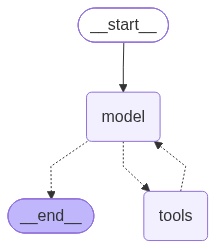

In [5]:
display(Image(agent.get_graph().draw_mermaid_png()))

## Part 3: memory

By default each call to `invoke` is a fresh start. To remember a conversation we give the agent a checkpointer, exactly as we did with the graph yesterday, and pass a `thread_id` so it knows which conversation we mean.

In [6]:
memory_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather],
    checkpointer=MemorySaver(),
    system_prompt="You are a travel assistant. Use your tools to answer questions about cities.",
)

config = {"configurable": {"thread_id": "trip-planning"}}
memory_agent.invoke({"messages": [{"role": "user", "content": "I am planning a trip to London."}]}, config=config)
result = memory_agent.invoke({"messages": [{"role": "user", "content": "What is the weather like where I am going on my trip?"}]}, config=config)
print(result["messages"][-1].content)

In London today, it’s **rainy and 14°C**.


## Part 4: structured output

When you want a typed object back rather than prose, pass a Pydantic model as `response_format`. The agent still does its work and uses its tools, then fills in your object. You read it from the `structured_response` key.

In [7]:
class CityReport(BaseModel):
    city: str = Field(description="The city name")
    weather: str = Field(description="A short weather description")
    population: str = Field(description="The population")

report_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather, get_population],
    response_format=CityReport,
)

result = report_agent.invoke({"messages": [{"role": "user", "content": "Give me a report on London."}]})
report = result["structured_response"]
print(report)
print("Just the weather:", report.weather)

city='London' weather='rainy, 14 degrees' population='8.9 million'
Just the weather: rainy, 14 degrees


## Part 5: middleware

Middleware is a powerful feature to shape an agent's behavior. It lets you run your own code at fixed points in the loop: before the model is called, after it answers, or around each tool call.

Here is a small piece of custom middleware that prints every tool call as it happens, so you can watch the agent at work. The `@wrap_tool_call` decorator wraps each tool call: we log it, then call `handler` to let it proceed.

In [8]:
@wrap_tool_call
def log_tool_calls(request, handler):
    call = request.tool_call
    print(f"  [middleware] calling {call['name']} with {call['args']}")
    return handler(request)

watched_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather, get_population],
    system_prompt="You are a travel assistant. Use your tools.",
    middleware=[log_tool_calls],
)

result = watched_agent.invoke({"messages": [{"role": "user", "content": "Weather and population of London and Rome?"}]})
print("\nFinal answer:", result["messages"][-1].content)

  [middleware] calling get_weather with {'city': 'London'}
  [middleware] calling get_population with {'city': 'London'}
  [middleware] calling get_weather with {'city': 'Rome'}
  [middleware] calling get_population with {'city': 'Rome'}

Final answer: Here you go:

- **London**: rainy, **14°C**; population **8.9 million**
- **Rome**: sunny, **27°C**; population **2.8 million**


LangChain also ships a range of ready made middleware, including `SummarizationMiddleware` to keep long conversations within the context window, `PIIMiddleware` to redact sensitive data, retry and call-limit middleware, and `HumanInTheLoopMiddleware` to pause for human approval.

## Before Part 6: Node and Playwright

The last part of this lab uses tools that live in a separate program, an MCP server, and that program runs on Node. Two quick checks before we start.

First, Node itself; you want v22 or later. If the cell below fails, install Node with one command:

- **Windows**, in PowerShell: `winget install OpenJS.NodeJS.LTS`
- **Mac**, in Terminal: `brew install node`
- **Linux**, or if neither works for you: see the guide at [setup/SETUP-node.md](../setup/SETUP-node.md)

After installing, quit Cursor completely and start it again, then reopen this notebook and re-run the lab from the top. That full restart matters: a freshly installed Node is invisible to a notebook that was already running, and restarting just the kernel is not enough.

In [9]:
!node --version
!npx --version

v24.14.1
11.11.0


Second, Playwright, Microsoft's browser automation framework. There is nothing to install: `npx` fetches it on demand, and it drives the copy of Chrome already on your machine. Chrome does not need to be running; Playwright launches its own.

The cell below proves the whole chain with no AI involved at all: Node runs Playwright, Playwright opens Chrome, loads Hacker News, and saves a screenshot. The first run takes a little longer while npx downloads the package.

If it complains that Chrome is not found, either install Chrome normally or run `npx playwright install chrome` in a terminal, then try again.

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png
⠙

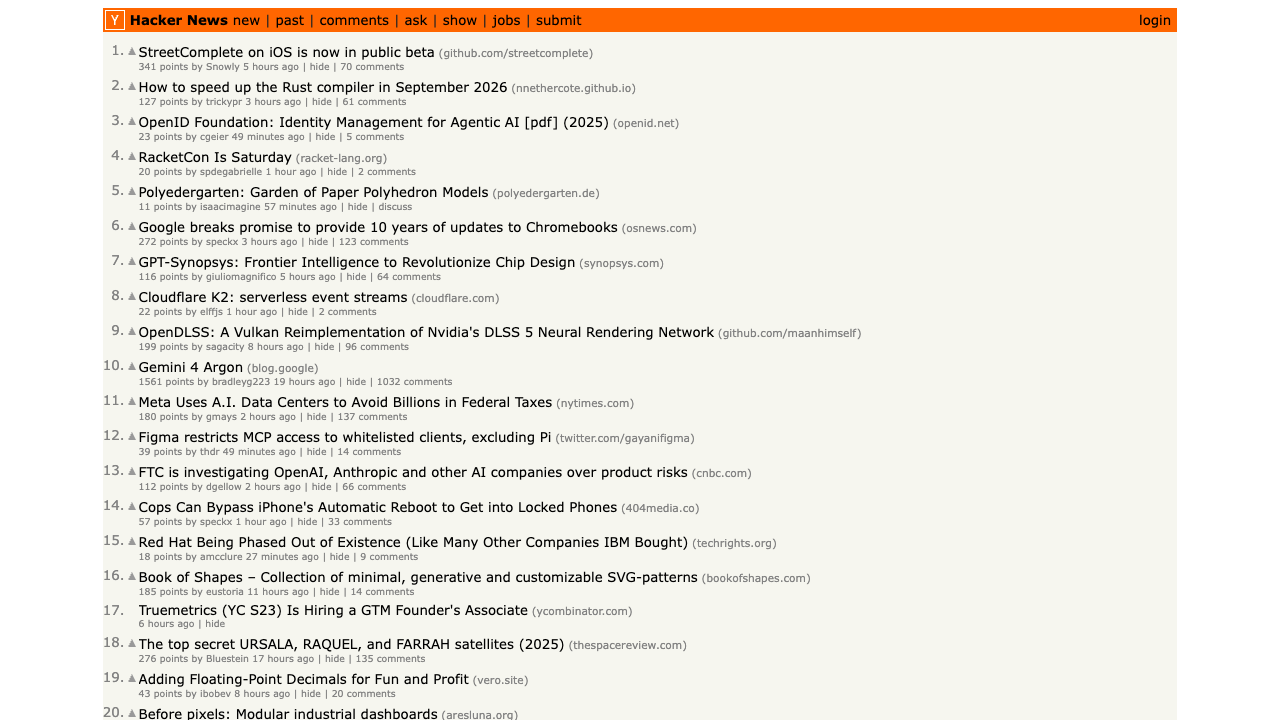

In [10]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

## Part 6: an MCP server, and a real browser

Tools do not have to be Python functions you write. The Model Context Protocol is a standard way for agents to use tools that live in a separate server. LangChain loads those tools with `langchain.mcp.MCPAdapter`, and from the agent's point of view they are just tools like any other.

We will connect to Microsoft's Playwright MCP server, which drives the same real browser you just smoke-tested. It runs headed by default, so you can watch it work; on a Linux box with no display it quietly falls back to headless. Because these tools talk to a separate process, they are async, so we load them with `await` and run the agent with `ainvoke`, which you met in Part 1.

This copy uses `langchain[mcp]>=1.4.3` with MCP 2. The MCP namespace is currently in beta, so an import warning is expected.

### Server logs in a notebook

On Windows, Jupyter stderr is not a regular file. We give the subprocess a log file through the supported FastMCP transport option. On Mac and Linux, server logs use stderr normally.

In [11]:
import sys
from pathlib import Path

mcp_log_file = Path("playwright_mcp.log") if sys.platform == "win32" else None

In [12]:
browser_transport = StdioTransport(
    command="npx",
    args=["-y", "@playwright/mcp@latest", "--isolated"],
    log_file=mcp_log_file,
)
client = MCPAdapter(browser_transport)

browser_tools = await client.list_tools()
print(f"Loaded {len(browser_tools)} browser tools:")
for t in browser_tools:
    print(" -", t.name)

Loaded 25 browser tools:
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_emulate_media
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_find
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for


Now we hand those browser tools to an ordinary `create_agent` and ask it to visit Hacker News and report what it finds. Watch the browser window open and navigate on its own.

In [13]:
browser_agent = create_agent(
    model="openai:gpt-5.5",
    tools=browser_tools,
    system_prompt="You are a web research assistant. Use the browser tools to complete the task, then report clearly.",
)

result = await browser_agent.ainvoke({"messages": [{"role": "user",
    "content": "Go to https://news.ycombinator.com and tell me the titles of the top three stories on the front page."}]})
print(result["messages"][-1].content)

The top three stories on Hacker News are:

1. StreetComplete on iOS is now in public beta
2. How to speed up the Rust compiler in September 2026
3. OpenID Foundation: Identity Management for Agentic AI [pdf] (2025)


## Recap, and where we are heading

In one lab you have built an agent in a single line, seen that it is really a LangGraph graph, given it tools, memory and structured output, shaped it with middleware, and let it drive a real browser through an MCP server. This is the layer you will reach for most often in your own work.

Tomorrow we go one layer higher. Deep Agents take create_agent and wrap it in a full harness for work that takes many steps.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Give the browser agent a checkpointer and a thread_id, then hold a short back and forth with it: ask it to open a site, then ask a follow up question about what it found, and confirm it remembers. For a bigger challenge, write a piece of middleware that refuses any navigation to a site you put on a block list, and prove it works.
            </span>
        </td>
    </tr>
</table>